# Voluntario Schrödinger

A continuación, expondremos los programas utilizados para la visualización de los resultados obtenidos a partir del programa originial

In [2]:
# Importamos los paquetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


## 1.- Autofunciones

A continuación, usaremos los siguientes programas para presentar los resultados obtenidos para las autofunciones

### 1.1.- Animación de la densidad de probabilidad, Parte Real y Parte Imaginaria

Generando animación, por favor espera... (esto puede tardar unos segundos)
¡Animación guardada con éxito!


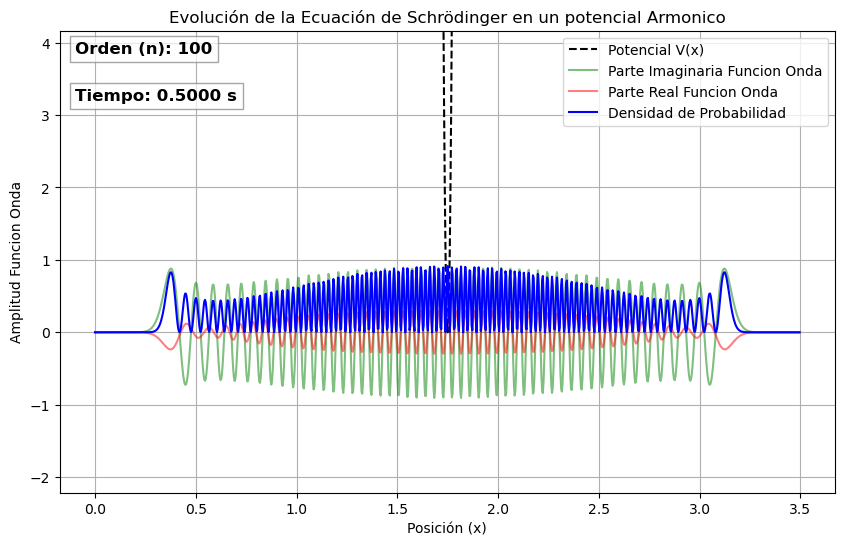

In [9]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_funcion = pd.read_csv("./Autofunciones/Orden_100/Autofuncion_Funcion_Onda.txt", sep="\t", header=0, names=["T", "x", "P", "R", "I"])

# Asigno nombres ['Posicion', 'V'] a las columnas de la función de onda para que sea fácil filtrarlas
df_potencial = pd.read_csv("./Autofunciones/Orden_100/Autofuncion_Potencial_Armonico.txt", sep="\t", header=0, names = ["x", "V"])

df_condiciones = pd.read_csv("./Autofunciones/Orden_100/Condiciones_Iniciales.txt", sep="\t", header=0, names = ["L", "dx", "dt", "n", "omega", "x_0"])
omega = df_condiciones["omega"].iloc[0]
x_0 = df_condiciones["x_0"].iloc[0]
n = df_condiciones["n"].iloc[0]

# Sacamos un array con los pasos temporales únicos
pasos = df_funcion["T"].unique()[::10]   # Coge cada 5 frames

# Obtengo el maximo de la amplitud de la densidad de probabilidad
max_val = max(df_funcion["I"].max(),df_funcion["R"].max(), df_funcion["P"].max())
min_val = min(df_funcion["I"].min(),df_funcion["R"].min(), df_funcion["P"].min())

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Plotear el potencial de fondo (se queda estático)
# iloc[:, 0] coge la primera columna (espacio j) e iloc[:, 1] coge la segunda (valor del potencial)
ax.plot(df_potencial.iloc[:, 0], df_potencial.iloc[:, 1], color='black', linestyle='--', label='Potencial V(x)')

texto_orden = ax.text(0.02, 0.95, f"Orden (n): {int(n)}", transform=ax.transAxes, 
                           fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Filtramos los datos de la función de onda solo para el primer fotograma (t=0)
datos_iniciales = df_funcion[df_funcion["T"] == pasos[0]]

# Ploteamos la función de onda.
imagniaria, = ax.plot(datos_iniciales["x"], datos_iniciales["I"], color='green', label='Parte Imaginaria Funcion Onda', alpha = 0.5)
real, = ax.plot(datos_iniciales["x"], datos_iniciales["R"], color='red', label='Parte Real Funcion Onda', alpha =0.5)
prob, = ax.plot(datos_iniciales["x"], datos_iniciales["P"], color='blue', label='Densidad de Probabilidad')

texto_tiempo = ax.text(0.02, 0.85, f"Tiempo: {pasos[0]:.4f} s", transform=ax.transAxes, 
                       fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Etiquetas y leyenda
ax.set_xlabel("Posición (x)")
plt.grid()
ax.set_ylabel("Amplitud Funcion Onda")
#ax.set_xlim(0, 1)   # Limite horizontal
ax.set_ylim(min_val*1.2,max_val*1.2)                                     # Maximo y minimo de probabilidad
ax.set_title("Evolución de la Ecuación de Schrödinger en un potencial Armonico")
ax.legend(loc='upper right')

# 3. DEFINIR LA FUNCIÓN DE ANIMACIÓN
def actualizar_frame(frame):
    # Filtramos la tabla para quedarnos solo con el instante de tiempo actual
    datos_fotograma = df_funcion[df_funcion["T"] == frame]
    
    # Actualizamos los datos X e Y de la línea roja
    imagniaria.set_data(datos_fotograma["x"], datos_fotograma["I"])
    real.set_data(datos_fotograma["x"], datos_fotograma["R"])
    prob.set_data(datos_fotograma["x"], datos_fotograma["P"])
    
    # Actualizar el texto del tiempo con el frame actual
    texto_tiempo.set_text(f"Tiempo: {frame:.4f} s")
    
    # CAMBIO 3: Devolvemos el texto junto con las líneas para el blitting
    return real, imagniaria, prob, texto_tiempo

# 4. CREAR Y GUARDAR EL GIF
# Usamos blit=True para que solo se redibuje lo que cambia (la onda roja), optimizando el proceso
anim = animation.FuncAnimation(fig, actualizar_frame, frames=pasos, interval=50, blit=True)

print("Generando animación, por favor espera... (esto puede tardar unos segundos)")
anim.save('./Autofunciones/Orden_100/Evolucion_Funcion_y_Probabilidad.gif', writer='pillow', fps=15)
print("¡Animación guardada con éxito!")

## 1.2.- Observables

A continuacion, representaremos los distintos observables para comprobar cada autofuncion

### 1.2.0.- Determinacion del mejor método de integración

A continuación, compararemos el error relativo del valor esperado de la posicion y de la energia (del momento no pq no), obtenido con los diferentes métodos de integracion. Lo haremos para varios órdenes del polinomio, para poder efectuar un análisis más profundo.

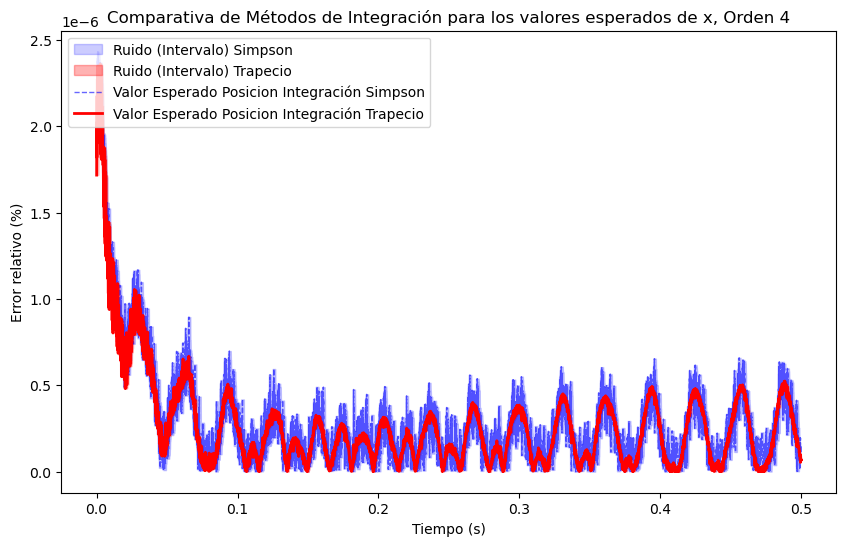

In [4]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observablesT = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observablesS = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Simpson.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# Valores esperados teoricos
x = 0.5
p = 0

error_x_T =  abs(df_observablesT["X"]-x)/x*100
error_x_S =  abs(df_observablesS["X"]-x)/x*100

# Tamaño de la ventana (ajusta este valor. Si tienes 10,000 datos, prueba con 100 o 500)
ventana = 20 

# Calcular la tendencia (Media móvil)
tendencia_T = error_x_T.rolling(window=ventana, center=True).mean()
tendencia_S = error_x_S.rolling(window=ventana, center=True).mean()

# Calcular el intervalo de ruido (Máximo y mínimo móvil)
max_T = error_x_T.rolling(window=ventana, center=True).max()
min_T = error_x_T.rolling(window=ventana, center=True).min()

max_S = error_x_S.rolling(window=ventana, center=True).max()
min_S = error_x_S.rolling(window=ventana, center=True).min()

# Limites del eje y
max_val = max(error_x_T.min(),error_x_T.max())
min_val = min(error_x_T.min(),error_x_T.min())
max_val = min_val+0.1*min_val
min_val = min_val-0.01*max_val

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Simpson en azul claro
ax.fill_between(df_observablesS["T"], min_S, max_S, color='blue', alpha=0.2, label='Ruido (Intervalo) Simpson')
# Trapecio en rojo claro
ax.fill_between(df_observablesT["T"], min_T, max_T, color='red', alpha=0.3, label='Ruido (Intervalo) Trapecio')

# Ploteamos la función de onda.
ax.plot(df_observablesS["T"], error_x_S, color='blue', linewidth=1, linestyle='--', label='Valor Esperado Posicion Integración Simpson', alpha = 0.6)
ax.plot(df_observablesT["T"], error_x_T, color='red',linewidth=2, label='Valor Esperado Posicion Integración Trapecio', alpha = 1)

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Error relativo (%)")
#ax.set_xlim(0.4, 0.5)   # Limite horizontal
#ax.set_ylim(0E-6,0.7E-6)                                     # Maximo y minimo de probabilidad
ax.set_title("Comparativa de Métodos de Integración para los valores esperados de x, Orden 4")
ax.legend(loc='upper left')

plt.savefig('./Autofunciones/Orden_4/Grafica_Error_Relativo_x.png')

plt.show()


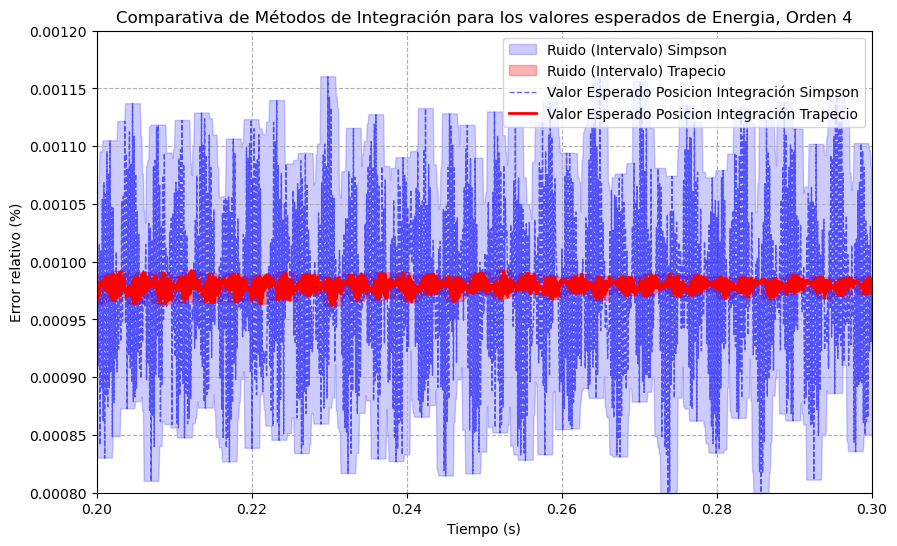

In [88]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observablesT = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observablesS = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Simpson.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# Valores esperados teoricos
x = 0.5
p = 0
E_0 = 100
E_1 = 300
E_2 = 500
E_3 = 700
E_4 = 900

ventana = 20

# Calcular la tendencia (Media móvil) - Ahora usando error_E
tendencia_T = error_E_T.rolling(window=ventana, center=True).mean()
tendencia_S = error_E_S.rolling(window=ventana, center=True).mean()

# Calcular el intervalo de ruido (Máximo y mínimo móvil)
max_T = error_E_T.rolling(window=ventana, center=True).max()
min_T = error_E_T.rolling(window=ventana, center=True).min()

max_S = error_E_S.rolling(window=ventana, center=True).max()
min_S = error_E_S.rolling(window=ventana, center=True).min()

error_E_T =  abs(df_observablesT["E"]-E_4)/E_4*100
error_E_S =  abs(df_observablesS["E"]-E_4)/E_4*100

# Limites del eje y
max_val = max(error_E_T.min(),error_E_T.max())
min_val = min(error_E_T.min(),error_E_T.min())
max_val = max_val+0.2*max_val
min_val = min_val-0.01*min_val

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Simpson en azul claro
ax.fill_between(df_observablesS["T"], min_S, max_S, color='blue', alpha=0.2, label='Ruido (Intervalo) Simpson')
# Trapecio en rojo claro
ax.fill_between(df_observablesT["T"], min_T, max_T, color='red', alpha=0.3, label='Ruido (Intervalo) Trapecio')

# Ploteamos la función de onda.
ax.plot(df_observablesS["T"], error_E_S, color='blue', linewidth=1, linestyle='--', label='Valor Esperado Posicion Integración Simpson',alpha = 0.6)
ax.plot(df_observablesT["T"], error_E_T, color='red',linewidth=2, label='Valor Esperado Posicion Integración Trapecio', alpha=1)

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Error relativo (%)")
ax.set_ylim(0.0008,0.0012)   # Limite horizontal
#ax.set_ylim(min_val,max_val) 
ax.set_xlim(0.2,0.3)                                     # Maximo y minimo de probabilidad
ax.set_title("Comparativa de Métodos de Integración para los valores esperados de Energia, Orden 4")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Orden_4/Grafica_Error_Relativo_E_zoom.png')

plt.show()


Tras realizar un análisis comparativo de la convergencia del error relativo entre los métodos de integración de Simpson y el Trapecio (Figuras X e Y), se observa que, si bien ambos métodos presentan una magnitud de error similar en el límite asintótico, el método del Trapecio exhibe un comportamiento significativamente más estable y suave a lo largo del tiempo. Mientras que el método de Simpson muestra oscilaciones de alta frecuencia en el error (atribuibles a la sensibilidad de sus pesos de integración a las pequeñas variaciones de la malla espacial), el método del Trapecio permite obtener una tendencia clara y una mayor relación señal-ruido en la medida. Por tanto, se selecciona el método del Trapecio como la opción óptima para el estudio del resto de observables, ya que su estabilidad numérica facilita un análisis posterior de los datos sin la necesidad de aplicar filtros de post-procesamiento adicionales que podrían introducir sesgos en la interpretación física.

### 1.2.1.- Valor Esperado de la Posición

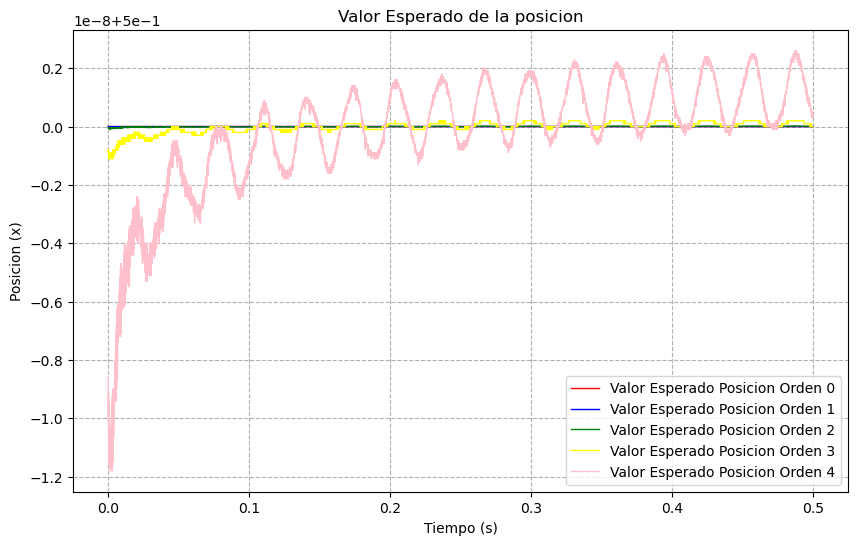

In [ ]:
#Valor Esperado Posicion

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["X"], color='red',linewidth=1, label='Valor Esperado Posicion Orden 0')
ax.plot(df_observables1["T"], df_observables1["X"], color='blue',linewidth=1, label='Valor Esperado Posicion Orden 1')
ax.plot(df_observables2["T"], df_observables2["X"], color='green',linewidth=1, label='Valor Esperado Posicion Orden 2')
ax.plot(df_observables3["T"], df_observables3["X"], color='yellow',linewidth=1, label='Valor Esperado Posicion Orden 3')
ax.plot(df_observables4["T"], df_observables4["X"], color='pink',linewidth=1, label='Valor Esperado Posicion Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Posicion (x)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado de la posicion")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Valor_Esperado_Posicion.png')

plt.show()



### 1.2.2.- Valor Esperado del Momento

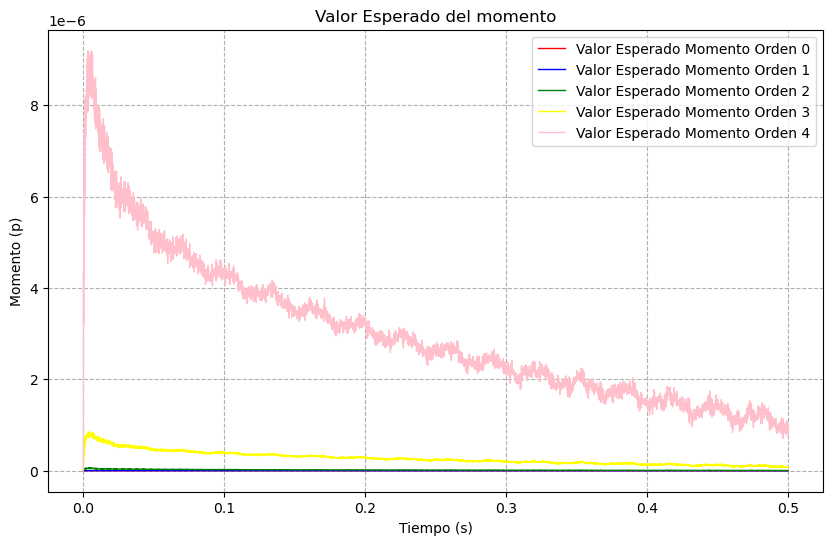

In [ ]:
# Valor Esperado Momento

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["P"], color='red',linewidth=1, label='Valor Esperado Momento Orden 0')
ax.plot(df_observables1["T"], df_observables1["P"], color='blue',linewidth=1, label='Valor Esperado Momento Orden 1')
ax.plot(df_observables2["T"], df_observables2["P"], color='green',linewidth=1, label='Valor Esperado Momento Orden 2')
ax.plot(df_observables3["T"], df_observables3["P"], color='yellow',linewidth=1, label='Valor Esperado Momento Orden 3')
ax.plot(df_observables4["T"], df_observables4["P"], color='pink',linewidth=1, label='Valor Esperado Momento Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Momento (p)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado del momento")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Valor_Esperado_Momento.png')

plt.show()

### 1.2.3.- Valor Esperado de la Energia

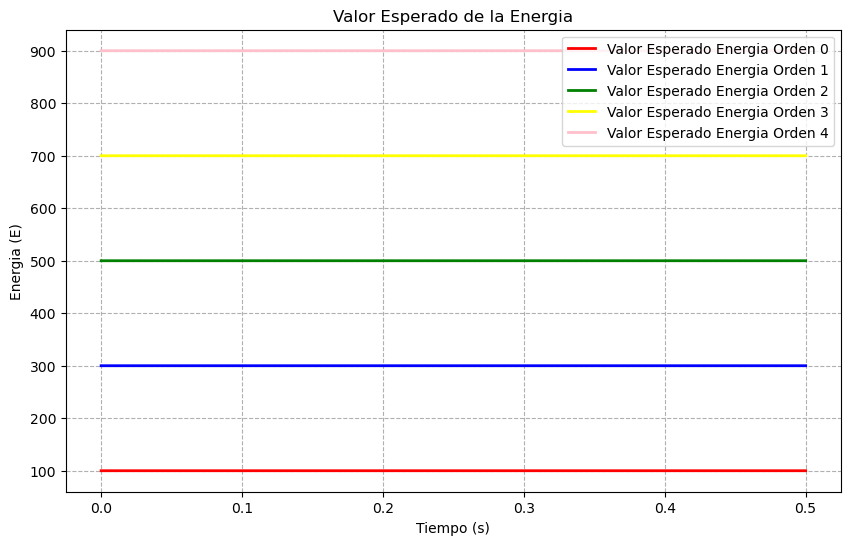

In [ ]:
# Valor Esperado Energia

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["E"], color='red',linewidth=2, label='Valor Esperado Energia Orden 0')
ax.plot(df_observables1["T"], df_observables1["E"], color='blue',linewidth=2, label='Valor Esperado Energia Orden 1')
ax.plot(df_observables2["T"], df_observables2["E"], color='green',linewidth=2, label='Valor Esperado Energia Orden 2')
ax.plot(df_observables3["T"], df_observables3["E"], color='yellow',linewidth=2, label='Valor Esperado Energia Orden 3')
ax.plot(df_observables4["T"], df_observables4["E"], color='pink',linewidth=2, label='Valor Esperado Energia Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Energia (E)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado de la Energia")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Valor_Esperado_Energia.png')

plt.show()



Vemos la comparacion relativa de los valores de la energia

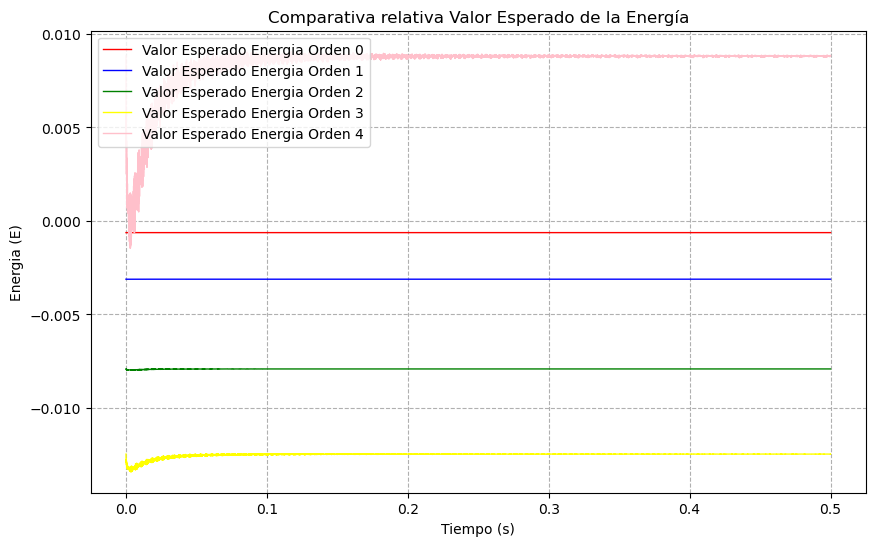

In [37]:
# Valor Esperado Energia

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

#Valores teoricos de energia
E_0 = 100
E_1 = 300
E_2 = 500
E_3 = 700
E_4 = 900

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], (df_observables0["E"]-E_0), color='red',linewidth=1, label='Valor Esperado Energia Orden 0')
ax.plot(df_observables1["T"], (df_observables1["E"]-E_1), color='blue',linewidth=1, label='Valor Esperado Energia Orden 1')
ax.plot(df_observables2["T"], (df_observables2["E"]-E_2), color='green',linewidth=1, label='Valor Esperado Energia Orden 2')
ax.plot(df_observables3["T"], (df_observables3["E"]-E_3), color='yellow',linewidth=1, label='Valor Esperado Energia Orden 3')
ax.plot(df_observables4["T"], (df_observables4["E"]-E_4), color='pink',linewidth=1, label='Valor Esperado Energia Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Energia (E)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comparativa relativa Valor Esperado de la Energía")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Valor_Esperado_Energia_relativa.png')

plt.show()



### 1.2.4.- Principio de Incertidumbre de Heidenberg

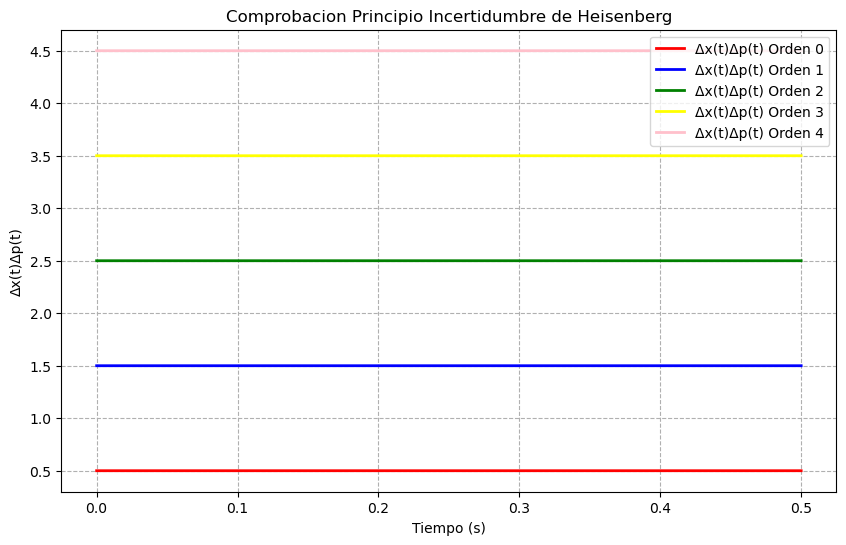

In [ ]:
# Principio Incertidumbre de Heisenberg

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["Heisenberg"], color='red',linewidth=2, label='Δx(t)Δp(t) Orden 0')
ax.plot(df_observables1["T"], df_observables1["Heisenberg"], color='blue',linewidth=2, label='Δx(t)Δp(t) Orden 1')
ax.plot(df_observables2["T"], df_observables2["Heisenberg"], color='green',linewidth=2, label='Δx(t)Δp(t) Orden 2')
ax.plot(df_observables3["T"], df_observables3["Heisenberg"], color='yellow',linewidth=2, label='Δx(t)Δp(t) Orden 3')
ax.plot(df_observables4["T"], df_observables4["Heisenberg"], color='pink',linewidth=2, label='Δx(t)Δp(t) Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Δx(t)Δp(t)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comprobacion Principio Incertidumbre de Heisenberg")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Principio_Heisenberg.png')

plt.show()



Comparacion relativa de Heisenberg

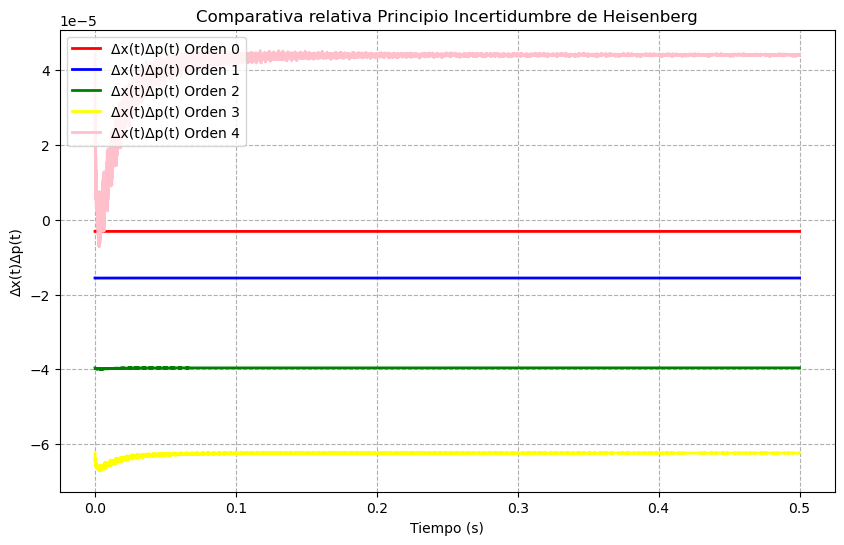

In [38]:
# Principio Incertidumbre de Heisenberg

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# Valores Teóricos Heisenberg
x_0 = 0.5
x_1= 1.5
x_2= 2.5
x_3= 3.5
x_4= 4.5

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["Heisenberg"]-x_0 , color='red',linewidth=2, label='Δx(t)Δp(t) Orden 0')
ax.plot(df_observables1["T"], df_observables1["Heisenberg"]-x_1, color='blue',linewidth=2, label='Δx(t)Δp(t) Orden 1')
ax.plot(df_observables2["T"], df_observables2["Heisenberg"]-x_2, color='green',linewidth=2, label='Δx(t)Δp(t) Orden 2')
ax.plot(df_observables3["T"], df_observables3["Heisenberg"]-x_3, color='yellow',linewidth=2, label='Δx(t)Δp(t) Orden 3')
ax.plot(df_observables4["T"], df_observables4["Heisenberg"]-x_4, color='pink',linewidth=2, label='Δx(t)Δp(t) Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Δx(t)Δp(t)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comparativa relativa Principio Incertidumbre de Heisenberg")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Principio_Heisenberg_relativa.png')

plt.show()



### 1.2.5.- Conservación de la Probabilidad

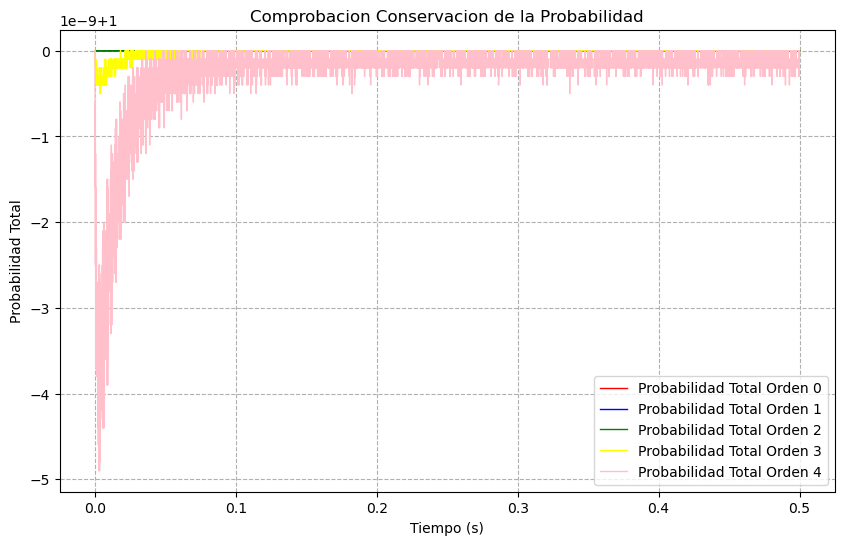

In [ ]:
# Probabilidad Total

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Autofunciones/Orden_0/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables1 = pd.read_csv("./Autofunciones/Orden_1/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables2 = pd.read_csv("./Autofunciones/Orden_2/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables3 = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
df_observables4 = pd.read_csv("./Autofunciones/Orden_4/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["prob"], color='red',linewidth=1, label='Probabilidad Total Orden 0')
ax.plot(df_observables1["T"], df_observables1["prob"], color='blue',linewidth=1, label='Probabilidad Total Orden 1')
ax.plot(df_observables2["T"], df_observables2["prob"], color='green',linewidth=1, label='Probabilidad Total Orden 2')
ax.plot(df_observables3["T"], df_observables3["prob"], color='yellow',linewidth=1, label='Probabilidad Total Orden 3')
ax.plot(df_observables4["T"], df_observables4["prob"], color='pink',linewidth=1, label='Probabilidad Total Orden 4')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Probabilidad Total")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comprobacion Conservacion de la Probabilidad")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Autofunciones/Observables/Conservacion_Probabilidad.png')

plt.show()



## 1.3.- Principio de Correspondecia

A continuacion vemos los codigos usados para el principio de correspondencia.

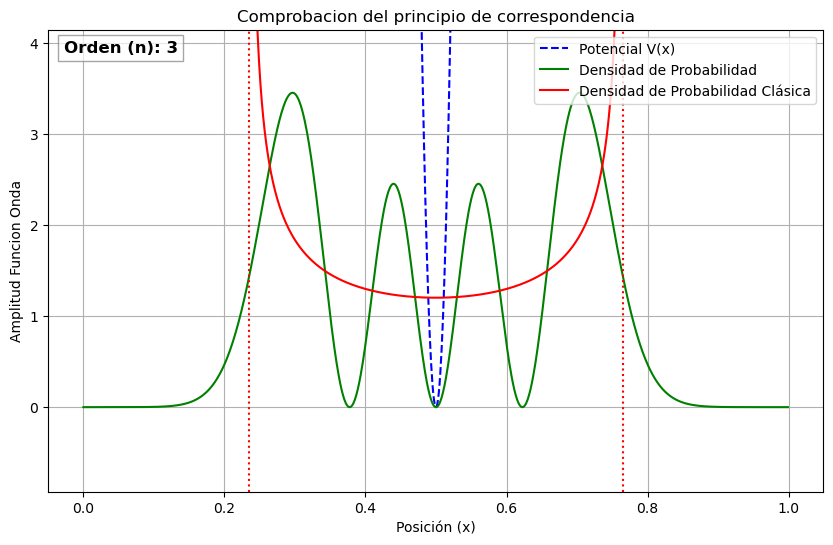

In [90]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_funcion = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Funcion_Onda.txt", sep="\t", header=0, names=["T", "x", "P", "R", "I"])

df_observables = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Observables_Integracion_Trapecio.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaP", "E", "Heisenberg"])
Energia = df_observables["E"]

# Asigno nombres ['Posicion', 'V'] a las columnas de la función de onda para que sea fácil filtrarlas
df_condiciones = pd.read_csv("./Autofunciones/Orden_3/Condiciones_Iniciales.txt", sep="\t", header=0, names = ["L", "dx", "dt", "n", "omega", "x_0"])
omega = df_condiciones["omega"].iloc[0]
x_0 = df_condiciones["x_0"].iloc[0]
n = df_condiciones["n"].iloc[0]

# Asigno nombres ['Posicion', 'V'] a las columnas de la función de onda para que sea fácil filtrarlas
df_potencial = pd.read_csv("./Autofunciones/Orden_3/Autofuncion_Potencial_Armonico.txt", sep="\t", header=0, names = ["x", "V"])

# Sacamos un array con los pasos temporales únicos
pasos = df_funcion["T"].unique()[::10]   # Coge cada 5 frames

# Obtengo el maximo de la amplitud de la densidad de probabilidad
max_val = max(df_funcion["I"].max(),df_funcion["R"].max(), df_funcion["P"].max())
min_val = min(df_funcion["I"].min(),df_funcion["R"].min(), df_funcion["P"].min())

# Filtramos los datos de la función de onda solo para el primer fotograma (t=0)
datos_iniciales = df_funcion[df_funcion["T"] == pasos[0]]

### PROBABILIDAD CLASICA
# Obtengo la distribucion de probabilidad clasica a partir de X y omega y el centro
E = np.mean(Energia)
A = 2*np.sqrt(E)/omega      # Variable A que la obtengo cogiendo el primer dato del valor esperado
x_arr = datos_iniciales["x"].values     # Tomo los valores en un array para que no de problemas

# Calculamos lo que va dentro de la raíz (el radicando)
radicando = A**2 - (x_arr - x_0)**2

# Creamos un array vacío para P_clas
P_clas = np.zeros_like(x_arr, dtype=float)

# Calculamos la fórmula solo donde el interior de la raíz es positivo
mascara_valida = radicando > 0
P_clas[mascara_valida] = 1 / (np.pi * np.sqrt(radicando[mascara_valida]))

# Donde la raíz sería negativa o cero, asignamos NaN (para que no se dibuje línea ahí)
P_clas[~mascara_valida] = np.nan

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Plotear el potencial de fondo (se queda estático)
# iloc[:, 0] coge la primera columna (espacio j) e iloc[:, 1] coge la segunda (valor del potencial)
ax.plot(df_potencial.iloc[:, 0], df_potencial.iloc[:, 1], color='blue', linestyle='--', label='Potencial V(x)')

texto_orden = ax.text(0.02, 0.95, f"Orden (n): {int(n)}", transform=ax.transAxes, 
                           fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Ploteamos la función de onda.
prob, = ax.plot(datos_iniciales["x"], datos_iniciales["P"], color='green', label='Densidad de Probabilidad')
clas, = ax.plot(datos_iniciales["x"], P_clas, color='red', label='Densidad de Probabilidad Clásica')
ax.axvline(x=x_0 - A, color='red', linestyle=':')  #Asintota inzquierda (cojo la amplitud A a la izquierda)
ax.axvline(x=x_0 + A, color='red', linestyle=':')  #Asintota derecha (cojo la amplitud A a la derecha)


# Etiquetas y leyenda
ax.set_xlabel("Posición (x)")
plt.grid()
ax.set_ylabel("Amplitud Funcion Onda")
#ax.set_xlim(0, 1)   # Limite horizontal
ax.set_ylim(min_val*0.5,max_val*1.2)                                     # Maximo y minimo de probabilidad
ax.set_title("Comprobacion del principio de correspondencia")
ax.legend(loc='upper right')


plt.savefig('./Autofunciones/Orden_3/Principio_Correspondencia.png')

plt.show()

# 2.- Gaussianas

## 2.1.- Representacion de las funciones de Onda

A continuacion, veremos unas series de animaciones de la evolucion temporal de las funciones de onda gaussianas.

Generando animación, por favor espera... (esto puede tardar unos segundos)
¡Animación guardada con éxito!


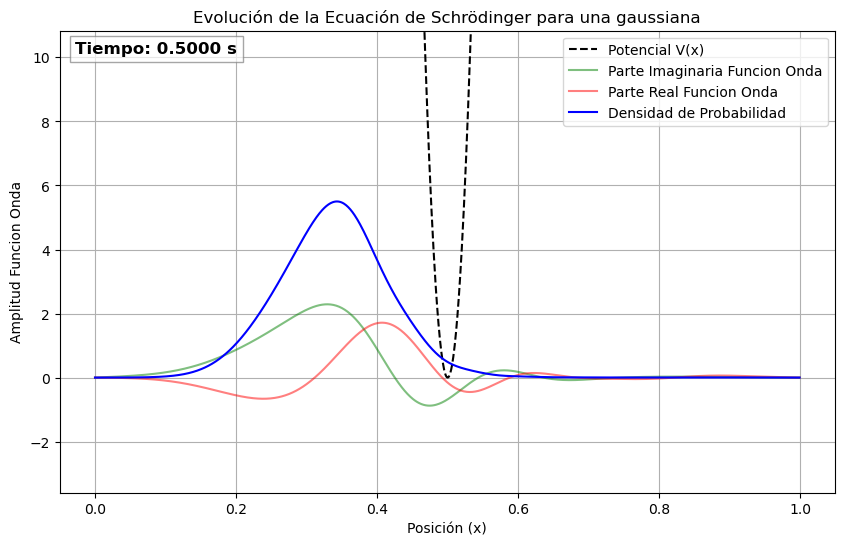

In [8]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_funcion = pd.read_csv("./Gaussianas/sigma116_centro03/Gauss_Funcion_Onda.txt", sep="\t", header=0, names=["T", "x", "P", "R", "I"])

# Asigno nombres ['Posicion', 'V'] a las columnas de la función de onda para que sea fácil filtrarlas
df_potencial = pd.read_csv("./Gaussianas/sigma116_centro03/Gauss_Potencial_Armonico.txt", sep="\t", header=0, names = ["x", "V"])

df_condiciones = pd.read_csv("./Gaussianas/sigma116_centro03/Condiciones_Iniciales.txt", sep="\t", header=0, names = ["L", "dx", "dt", "n", "omega", "x_0"])
omega = df_condiciones["omega"].iloc[0]
x_0 = df_condiciones["x_0"].iloc[0]
n = df_condiciones["n"].iloc[0]

# Sacamos un array con los pasos temporales únicos
pasos = df_funcion["T"].unique()[::10]   # Coge cada 5 frames

# Obtengo el maximo de la amplitud de la densidad de probabilidad
max_val = max(df_funcion["I"].max(),df_funcion["R"].max(), df_funcion["P"].max())
min_val = min(df_funcion["I"].min(),df_funcion["R"].min(), df_funcion["P"].min())

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Plotear el potencial de fondo (se queda estático)
# iloc[:, 0] coge la primera columna (espacio j) e iloc[:, 1] coge la segunda (valor del potencial)
ax.plot(df_potencial.iloc[:, 0], df_potencial.iloc[:, 1], color='black', linestyle='--', label='Potencial V(x)')

#texto_orden = ax.text(0.02, 0.95, f"Orden (n): {int(n)}", transform=ax.transAxes, 
#                           fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Filtramos los datos de la función de onda solo para el primer fotograma (t=0)
datos_iniciales = df_funcion[df_funcion["T"] == pasos[0]]

# Ploteamos la función de onda.
imagniaria, = ax.plot(datos_iniciales["x"], datos_iniciales["I"], color='green', label='Parte Imaginaria Funcion Onda', alpha = 0.5)
real, = ax.plot(datos_iniciales["x"], datos_iniciales["R"], color='red', label='Parte Real Funcion Onda', alpha =0.5)
prob, = ax.plot(datos_iniciales["x"], datos_iniciales["P"], color='blue', label='Densidad de Probabilidad')

texto_tiempo = ax.text(0.02, 0.95, f"Tiempo: {pasos[0]:.4f} s", transform=ax.transAxes, 
                       fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))

# Etiquetas y leyenda
ax.set_xlabel("Posición (x)")
plt.grid()
ax.set_ylabel("Amplitud Funcion Onda")
#ax.set_xlim(0, 1)   # Limite horizontal
ax.set_ylim(min_val*1.2,max_val*1.2)                                     # Maximo y minimo de probabilidad
ax.set_title("Evolución de la Ecuación de Schrödinger para una gaussiana")
ax.legend(loc='upper right')

# 3. DEFINIR LA FUNCIÓN DE ANIMACIÓN
def actualizar_frame(frame):
    # Filtramos la tabla para quedarnos solo con el instante de tiempo actual
    datos_fotograma = df_funcion[df_funcion["T"] == frame]
    
    # Actualizamos los datos X e Y de la línea roja
    imagniaria.set_data(datos_fotograma["x"], datos_fotograma["I"])
    real.set_data(datos_fotograma["x"], datos_fotograma["R"])
    prob.set_data(datos_fotograma["x"], datos_fotograma["P"])
    
    # Actualizar el texto del tiempo con el frame actual
    texto_tiempo.set_text(f"Tiempo: {frame:.4f} s")
    
    # CAMBIO 3: Devolvemos el texto junto con las líneas para el blitting
    return real, imagniaria, prob, texto_tiempo

# 4. CREAR Y GUARDAR EL GIF
# Usamos blit=True para que solo se redibuje lo que cambia (la onda roja), optimizando el proceso
anim = animation.FuncAnimation(fig, actualizar_frame, frames=pasos, interval=50, blit=True)

print("Generando animación, por favor espera... (esto puede tardar unos segundos)")
anim.save('./Gaussianas/sigma116_centro03/Evolucion_Funcion_y_Probabilidad.gif', writer='pillow', fps=15)
print("¡Animación guardada con éxito!")

### 2.1.0.- Comprobacion mejor Valor Esperado Posicion 

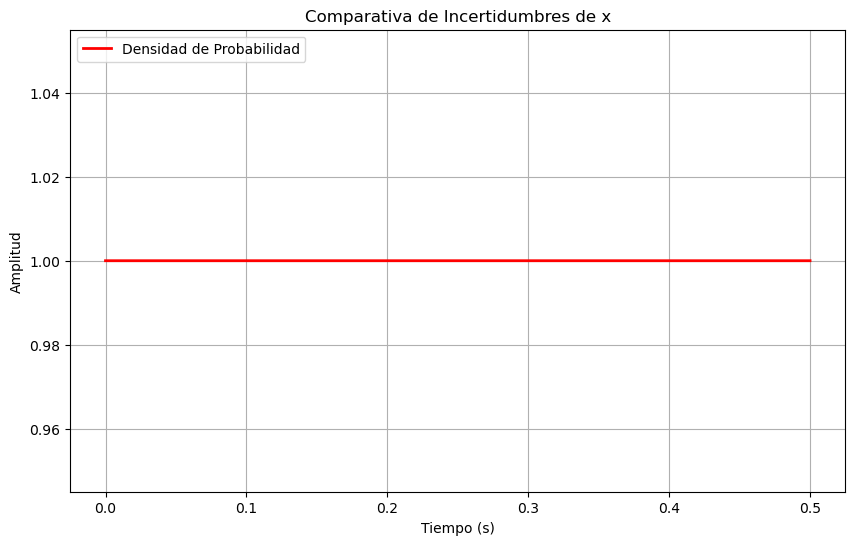

In [ ]:
# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables = pd.read_csv("./Gaussianas/sigma110_centro05/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# Limites del eje y
#max_val = max(error_x_T.min(),error_x_T.max())
#min_val = min(error_x_T.min(),error_x_T.min())
#max_val = min_val+0.1*min_val
#min_val = min_val-0.01*max_val

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables["T"], df_observables["prob"], color='red',linewidth=2, label='Densidad de Probabilidad')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Amplitud")
ax.grid()
# ax.set_xlim(0, 1)   # Limite horizontal
#ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Conservación de Probabilidad")
ax.legend(loc='upper left')

plt.savefig('./Gaussianas/sigma110_centro05/Comparativa_Incertidumbre_x.png')

plt.show()


### 2.2.1.- Valor esperado posición

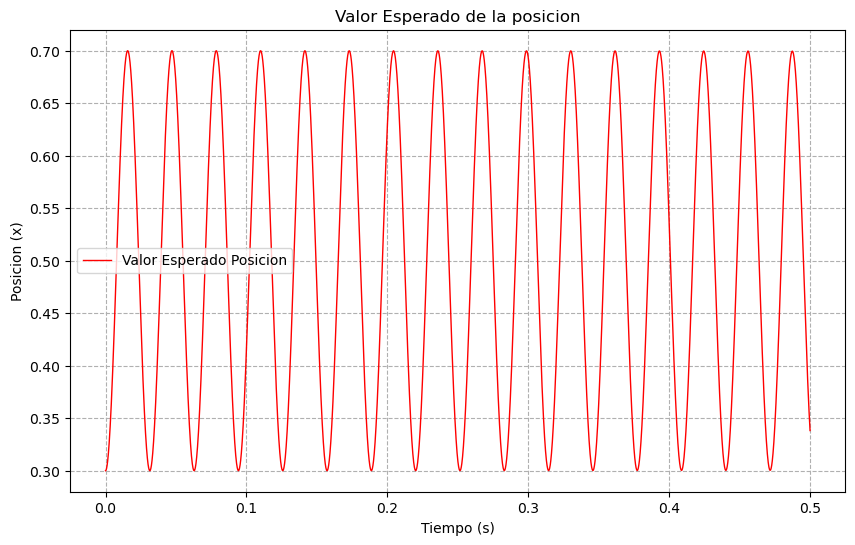

In [8]:
#Valor Esperado Posicion

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Gaussianas/sigma1w_centro03/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["X"], color='red',linewidth=1, label='Valor Esperado Posicion')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Posicion (x)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado de la posicion")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Gaussianas/sigma1w_centro03/Valor_Esperado_Posicion.png')

plt.show()



### 2.1.2.- Valor Esperado Momento

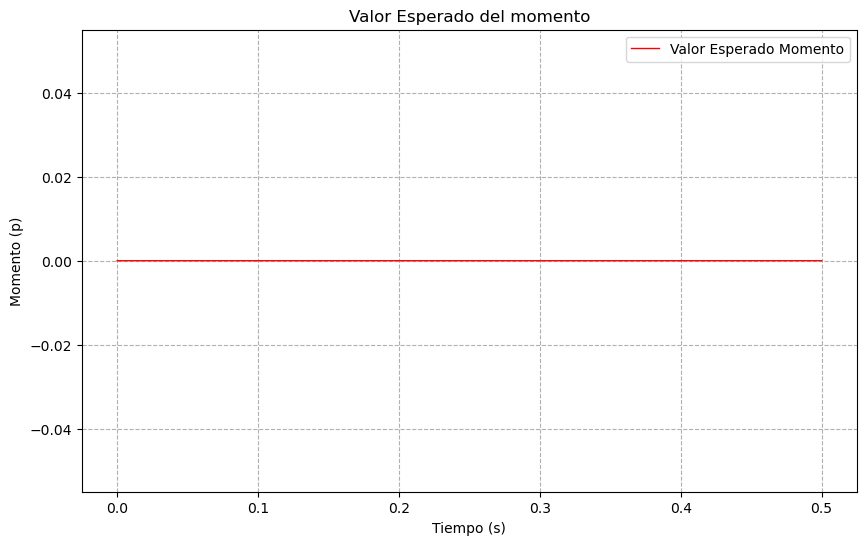

In [10]:
# Valor Esperado Momento

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Gaussianas/sigma116_centro05/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["P"], color='red',linewidth=1, label='Valor Esperado Momento')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Momento (p)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado del momento")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Gaussianas/sigma116_centro05/Valor_Esperado_Momento.png')

plt.show()

### 2.2.3.- Valor Esperado Energías

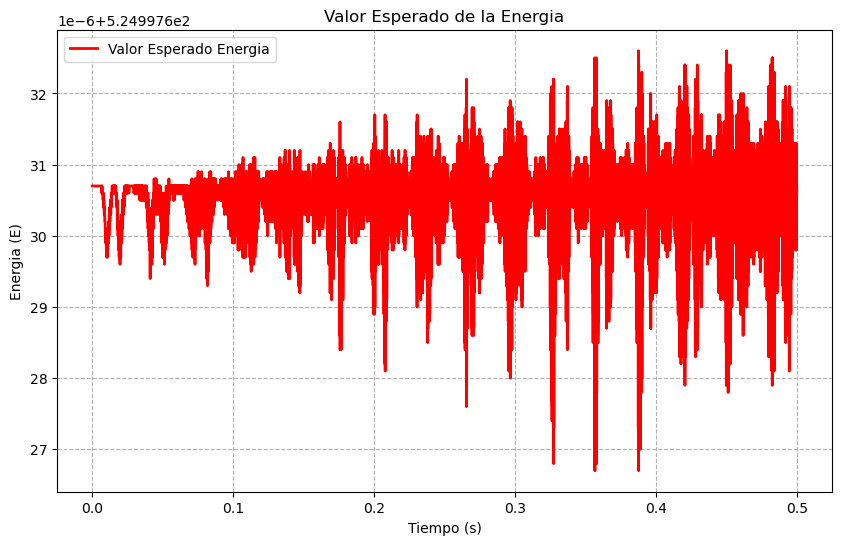

In [6]:
# Valor Esperado Energia

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Gaussianas/sigma1w_centro03/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["E"], color='red',linewidth=2, label='Valor Esperado Energia')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Energia (E)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Valor Esperado de la Energia")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Gaussianas/sigma1w_centro03/Valor_Esperado_Energia.png')

plt.show()



### 2.1.4.- Principio de Incertidumbre de Heisenberg

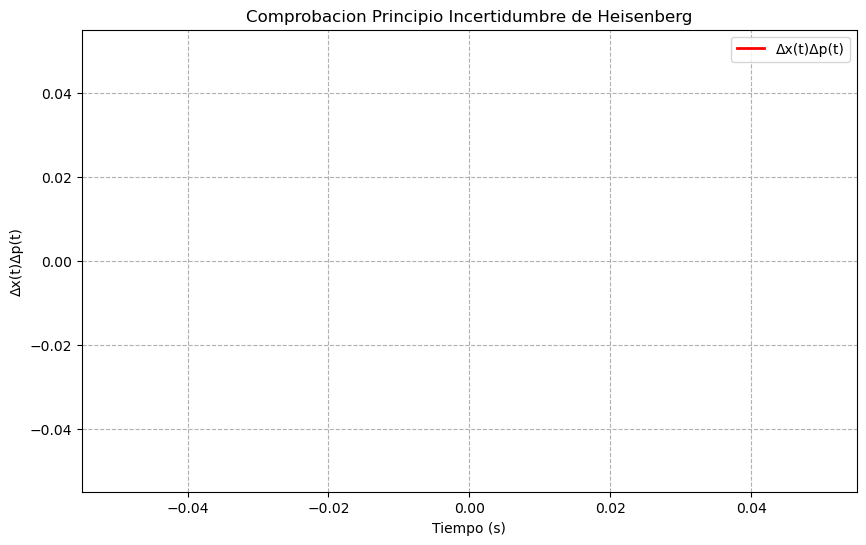

In [4]:
# Principio Incertidumbre de Heisenberg

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Gaussianas/pruebas/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["Heisenberg"], color='red',linewidth=2, label='Δx(t)Δp(t)')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Δx(t)Δp(t)")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comprobacion Principio Incertidumbre de Heisenberg")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Gaussianas/pruebas/Principio_Heisenberg.png')

plt.show()



### 2.1.5.- Conservacion de la Probabilidad

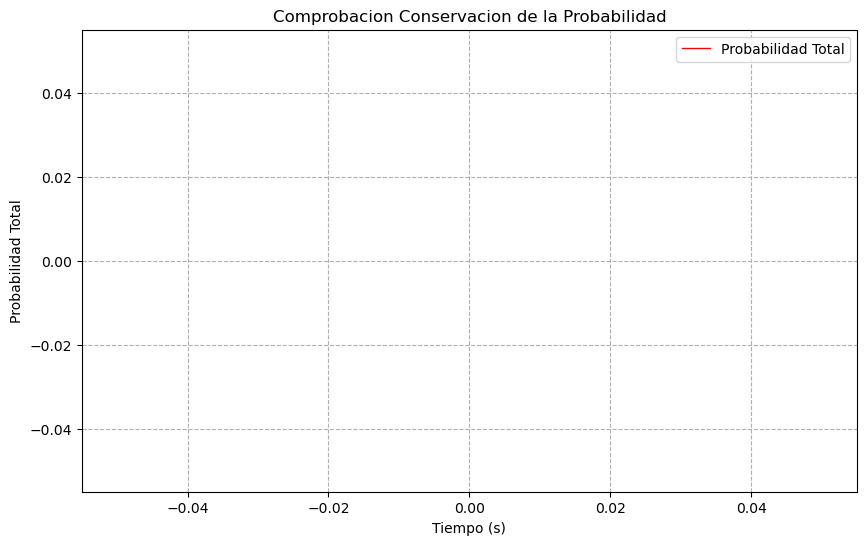

In [3]:
# Probabilidad Total

# 1. LEER LOS DATOS
# Asigno nombres ['Tiempo', 'Posicion', 'Probabilidad', 'Real', 'Imaginaria'] a las columnas de la función de onda para que sea fácil filtrarlas
df_observables0 = pd.read_csv("./Gaussianas/pruebas/Gauss_Observables.txt", sep="\t", header=0, names=["T", "prob", "X", "P", "DeltaX", "DeltaX_Gauss", "DeltaP", "E", "Heisenberg"])

# 2. PREPARAR EL GRÁFICO
fig, ax = plt.subplots(figsize=(10, 6))

# Ploteamos la función de onda.
ax.plot(df_observables0["T"], df_observables0["prob"], color='red',linewidth=1, label='Probabilidad Total')

# Etiquetas y leyenda
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Probabilidad Total")
# ax.set_xlim(0, 1)   # Limite horizontal
# ax.set_ylim(min_val,max_val)                                     # Maximo y minimo de probabilidad
ax.set_title("Comprobacion Conservacion de la Probabilidad")
ax.legend()
plt.grid(linestyle = "--")

plt.savefig('./Gaussianas/pruebas/Conservacion_Probabilidad.png')

plt.show()

